<a href="https://colab.research.google.com/github/devmurarijay13/pytorch-deep-learning/blob/main/fmnist_simple_ann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install torchinfo

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from torchinfo import summary
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim

In [24]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'using device : {device}')

using device : cpu


In [4]:
torch.manual_seed(42)

In [14]:
df = pd.read_csv('/content/fashion-mnist_train.csv')

In [15]:
df.sample(5)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
31129,4,0,0,0,0,0,2,0,6,116,...,0,0,0,0,87,133,128,47,0,0
47942,6,0,0,0,0,0,0,0,1,0,...,1,0,0,71,0,0,0,0,0,0
26029,1,0,0,0,0,0,0,0,0,0,...,182,40,0,0,0,0,0,0,0,0
38187,0,0,0,0,1,0,0,0,0,0,...,47,19,0,0,0,0,0,0,0,0
37515,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
df.shape

(60000, 785)

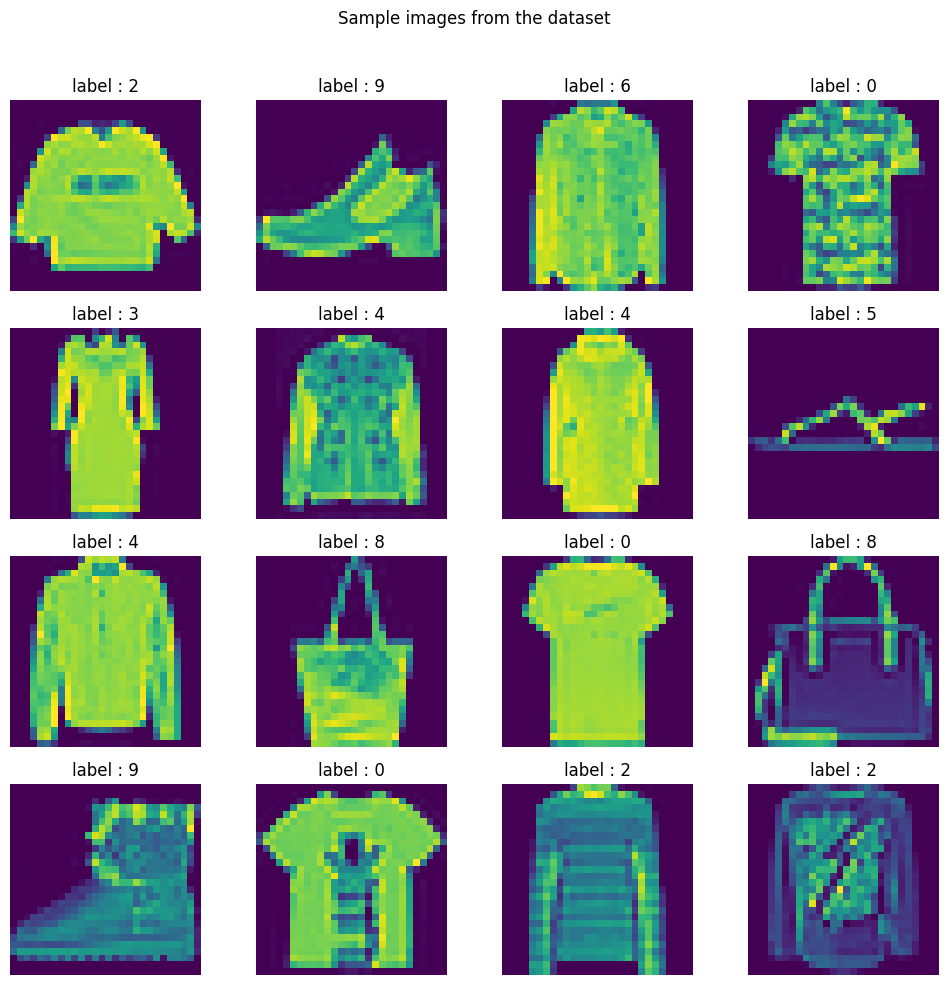

In [17]:
fig, axes = plt.subplots(4,4,figsize=(10,10))
fig.suptitle('Sample images from the dataset')

for i, ax in enumerate(axes.flat):
    image = df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(image)
    ax.axis('off')
    ax.set_title(f"label : {df.iloc[i,0]}")

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [18]:
X = df.drop(columns=['label'])
y = df['label']

In [19]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
X_train = X_train/255.0
X_test = X_test/255.0

In [21]:
class CustomDataset(Dataset):

    def __init__(self,features,labels):
        self.features = torch.tensor(features.values,dtype=torch.float32)
        self.labels = torch.tensor(labels.values,dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self,idx):
        return self.features[idx],self.labels[idx]

In [22]:
train_dataset = CustomDataset(X_train,y_train)
test_dataset = CustomDataset(X_test,y_test)

In [23]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True,pin_memory=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False,pin_memory=True)

In [25]:
learning_rate = 0.01
epochs = 30

In [26]:
class NeuralNetwork(nn.Module):

    def __init__(self,n_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(n_dim,128),
            nn.BatchNorm1d(num_features=128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128,64),
            nn.BatchNorm1d(num_features=64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64,10),
        )

    def forward(self,X):
        return self.model(X)


In [27]:
model = NeuralNetwork(X_train.shape[1])

# model = model.to(device)

optimizer = optim.Adam(model.parameters(),lr=learning_rate)
criterion = nn.CrossEntropyLoss()

In [34]:
summary(model)

Layer (type:depth-idx)                   Param #
NeuralNetwork                            --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       100,480
│    └─BatchNorm1d: 2-2                  256
│    └─ReLU: 2-3                         --
│    └─Dropout: 2-4                      --
│    └─Linear: 2-5                       8,256
│    └─BatchNorm1d: 2-6                  128
│    └─ReLU: 2-7                         --
│    └─Dropout: 2-8                      --
│    └─Linear: 2-9                       650
Total params: 109,770
Trainable params: 109,770
Non-trainable params: 0

In [30]:
#### training loop

for epoch in range(epochs):
    total_epoch_loss = 0

    for batch_features,batch_labels in train_loader:
        output = model(batch_features) ### forward pass
        loss = criterion(output,batch_labels) ### loss calculation

        optimizer.zero_grad() ### backpropagation
        loss.backward()

        optimizer.step()### upgrade grads

        total_epoch_loss = total_epoch_loss + loss.item()

    avg_loss = total_epoch_loss/len(train_loader)
    print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')

Epoch: 1 , Loss: 0.4424266510605812
Epoch: 2 , Loss: 0.41508226280411087
Epoch: 3 , Loss: 0.39906053720911344
Epoch: 4 , Loss: 0.3838859602858623
Epoch: 5 , Loss: 0.36590481117367746
Epoch: 6 , Loss: 0.36099485638240975
Epoch: 7 , Loss: 0.35155961820979914
Epoch: 8 , Loss: 0.3447625857243935
Epoch: 9 , Loss: 0.33723923776795467
Epoch: 10 , Loss: 0.3276113177289565
Epoch: 11 , Loss: 0.32347867424289384
Epoch: 12 , Loss: 0.3167989389846722
Epoch: 13 , Loss: 0.310950678465267
Epoch: 14 , Loss: 0.30577199450631937
Epoch: 15 , Loss: 0.30363862501333155
Epoch: 16 , Loss: 0.30077650236338377
Epoch: 17 , Loss: 0.29484103112171095
Epoch: 18 , Loss: 0.2955694302593668
Epoch: 19 , Loss: 0.28872092104454833
Epoch: 20 , Loss: 0.28076085474342105
Epoch: 21 , Loss: 0.2787654248550534
Epoch: 22 , Loss: 0.2817455204029878
Epoch: 23 , Loss: 0.2754899543101589
Epoch: 24 , Loss: 0.27572080869476
Epoch: 25 , Loss: 0.26631840033084153
Epoch: 26 , Loss: 0.2678277117709319
Epoch: 27 , Loss: 0.2614511293023824

In [31]:
model.eval()

NeuralNetwork(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [32]:
total = 0
correct = 0

with torch.no_grad():

    for batch_features, batch_labels in test_loader:

        outputs = model(batch_features)

        _,predicted = torch.max(outputs,1)

        total += batch_labels.shape[0]

        correct += (predicted == batch_labels).sum().item()


print(correct/total)

0.8925833333333333


In [33]:
total = 0
correct = 0

with torch.no_grad():

    for batch_features, batch_labels in train_loader:

        outputs = model(batch_features)

        _,predicted = torch.max(outputs,1)

        total += batch_labels.shape[0]

        correct += (predicted == batch_labels).sum().item()


print(correct/total)

0.9372708333333334
